# Projeto: Análise de Dados Brazilian E-Commerce Public Dataset by Olist

## 1. Carregamento dos Dados



In [1]:
# Importando Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

project_path = '/content/drive/MyDrive/olist_project'
os.makedirs(project_path, exist_ok=True)

os.listdir(project_path)

['product_category_name_translation.csv',
 'olist_sellers_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_order_reviews_dataset.csv']

In [4]:
df_payments     = pd.read_csv(f'{project_path}/olist_order_payments_dataset.csv')
df_products     = pd.read_csv(f'{project_path}/olist_products_dataset.csv')
df_reviews      = pd.read_csv(f'{project_path}/olist_order_reviews_dataset.csv')
df_customers    = pd.read_csv(f'{project_path}/olist_customers_dataset.csv')
df_orders       = pd.read_csv(f'{project_path}/olist_orders_dataset.csv')
df_items        = pd.read_csv(f'{project_path}/olist_order_items_dataset.csv')
df_sellers      = pd.read_csv(f'{project_path}/olist_sellers_dataset.csv')
df_translation  = pd.read_csv(f'{project_path}/product_category_name_translation.csv')
df_geolocation  = pd.read_csv(f'{project_path}/olist_geolocation_dataset.csv')

In [5]:
os.listdir('/content')

['.config', 'drive', 'sample_data']

## 1.1 Visualizando e Validando os Datasets

In [6]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


### Dataset: Payments

**Aplicação na análise:**  
Este dataset será utilizado como base exploratória para identificar padrões nos métodos de pagamento e avaliar tendências temporais associadas ao volume financeiro.


In [7]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### Dataset: Products

**Não Priorizado:**  
O dataset de produtos apresenta informações majoritariamente relacionadas a dimensões físicas e peso, que não são o foco central desta análise no momento.  

No entanto, a coluna `product_category_name` pode ser relevante em etapas posteriores para segmentações por categoria de produto e análises comparativas, motivo pelo qual o dataset foi mantido disponível no projeto.


In [8]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### Dataset: Reviews

**Aplicação na análise:**  
Este dataset será utilizado para analisar o comportamento das avaliações e identificar possíveis relações entre a experiência do cliente, o volume de pedidos e o desempenho das vendas, em conjunto com os demais dados do projeto.

In [9]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Dataset: Customers

**Aplicação na análise:**  
Dataset utilizado para apoiar análises relacionadas ao perfil e à distribuição dos consumidores, possibilitando cruzamentos com volume de pedidos, localização e comportamento de compra.

In [10]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Dataset: Orders

**Aplicação na análise:**  
Dataset central do projeto, utilizado como base para análises de volume de pedidos, status de entrega e relações temporais com os demais datasets.

In [11]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Dataset: Items

**Aplicação na análise:**  
Dataset utilizado para análises de valores dos pedidos, frete e composição financeira, permitindo relacionamentos com pedidos, vendedores e comportamento de vendas.

In [12]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Dataset: Sellers

**Aplicação na análise:**  
Dataset utilizado para análises relacionadas aos vendedores, incluindo distribuição geográfica e possíveis impactos no volume de pedidos e desempenho comercial.

In [13]:
df_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Dataset: Translation
**Não Utilizado:**  
Por se tratar de uma tabela de tradução de categorias e nomes de produtos, e não ser o foco principal para o público-alvo deste projeto, este dataset não foi priorizado nesta etapa da análise.

In [14]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


### Dataset: Geolocation

**Não Utilizado:**  
Neste projeto, foi priorizado o uso das informações de localização presentes nas tabelas de vendedores e consumidores, não sendo explorada, neste momento, a geolocalização detalhada dos demais dados.

## 1.2 Prioridade e Preparação dos Datasets

Antes de iniciar a limpeza e transformação dos dados, foi definida uma ordem de prioridade entre os datasets selecionados.  
Essa priorização tem como objetivo estruturar o processo de preparação, considerando dependências entre tabelas, relevância analítica e consistência dos relacionamentos.


1. **Orders**  
   Dataset central do projeto, utilizado como base para validação temporal, status dos pedidos e relacionamento com os demais dados.

2. **Items**  
   Dataset diretamente ligado aos pedidos, essencial para análises de valores, frete e composição financeira.

3. **Payments**  
   Dataset utilizado para validar métodos de pagamento e valores associados aos pedidos.

4. **Reviews**  
   Dataset utilizado para análise de avaliações e sua relação com pedidos e desempenho de vendas.

5. **Customers**  
   Dataset utilizado para análises relacionadas ao perfil e à localização dos consumidores.

6. **Sellers**  
   Dataset utilizado para análises relacionadas aos vendedores e sua distribuição geográfica.


### 1.2.1 Preparação e Qualidade dos Dados - Orders


In [15]:
# Inspeção inicial da estrutura do dataset
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [16]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
# Verificação de registros nulos
df_orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [18]:
# Verificação de duplicatas
df_orders.duplicated().sum()

np.int64(0)

In [19]:
df_orders['order_id'].duplicated().sum()

np.int64(0)

In [20]:
# Conversão de colunas para datetime
order_datas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

df_orders[order_datas] = df_orders[order_datas].apply(
    pd.to_datetime, errors='coerce'
)


In [21]:
# Validação do range temporal dos dados
df_orders[order_datas].agg(['min', 'max'])

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12


In [22]:
# Análise da distribuição do status dos pedidos
df_orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [23]:
# Validação final da estrutura e tipos de dados
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


#### **Observação - Orders**

A presença de valores nulos nas colunas de datas da tabela `orders` é **esperada dentro do contexto do processo operacional** dos pedidos.  
Essas datas representam diferentes etapas do ciclo de vida de uma ordem (aprovação, envio, entrega, estimativa, entre outras).

Nem todos os pedidos percorrem todas as etapas até a conclusão, seja por **cancelamentos, problemas logísticos, atrasos operacionais ou interrupções no fluxo**.  
Dessa forma, a existência de valores ausentes **não caracteriza inconsistência nos dados**, mas reflete o estado real dos pedidos ao longo do processo.

### 1.2.2 Preparação e Qualidade dos Dados - Items

In [24]:
# Inspeção inicial da estrutura do dataset
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [25]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [26]:
# Verificação de registros nulos
df_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [27]:
# Verificação de duplicatas
df_items.duplicated().sum()

np.int64(0)

In [28]:
df_items['order_id'].duplicated().sum()

np.int64(13984)

In [29]:
df_items['product_id'].duplicated().sum()

np.int64(79699)

In [30]:
# Conversão de colunas para datetime
df_items['shipping_limit_date'] = pd.to_datetime(
    df_items['shipping_limit_date'], errors='coerce'
)

In [31]:
# Validação do range temporal dos dados
df_items['shipping_limit_date'].min(), df_items['shipping_limit_date'].max()

(Timestamp('2016-09-19 00:15:34'), Timestamp('2020-04-09 22:35:08'))

In [32]:
# Validação da distribuição dos valores numéricos
df_items[['price','freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [33]:
# Validação final da estrutura e tipos de dados
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### **Observação - Items**

A presença de valores duplicados em `order_id` nesta tabela é **esperada e legítima**.  
Isso ocorre porque a tabela `items` representa **itens individuais de um pedido**, e não o pedido como uma entidade única.

Dessa forma, um mesmo `order_id` pode aparecer múltiplas vezes, cada uma correspondendo a um **produto distinto** dentro da mesma compra.  
Essas duplicidades **não indicam erro de dados** e devem ser consideradas corretamente durante agregações, junções e análises posteriores.

### 1.2.3 Preparação e Qualidade dos Dados - Payments

In [34]:
# Inspeção inicial da estrutura do dataset
df_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [35]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [36]:
# Verificação de registros nulos
df_payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [37]:
# Verificação de duplicatas
df_payments.duplicated().sum()

np.int64(0)

In [38]:
df_payments['order_id'].duplicated().sum()

np.int64(4446)

In [39]:
df_payments.duplicated(
    subset=['order_id', 'payment_sequential']
).sum()

np.int64(0)

In [40]:
# Validação da distribuição dos valores numéricos
df_payments[['payment_sequential','payment_value','payment_installments']].describe()

,payment_sequential,payment_value,payment_installments
count,103886.000000,103886.000000,103886.000000
mean,1.092679,154.100380,2.853349
std,0.706584,217.494064,2.687051
min,1.000000,0.000000,0.000000
25%,1.000000,56.790000,1.000000
50%,1.000000,100.000000,1.000000
75%,1.000000,171.837500,4.000000
max,29.000000,13664.080000,24.000000


In [41]:
# Análise da distribuição das formas de pagamento
df_payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [42]:
# Análise da distribuição das parcelas de pagamento
df_payments['payment_installments'].value_counts().sort_index()

,count
payment_installments,
0,2
1,52546
2,12413
3,10461
4,7098
5,5239
6,3920
7,1626
8,4268


In [43]:
# Verificação de consistência da sequência de pagamentos por pedido
seq = df_payments.groupby('order_id')['payment_sequential']

(seq.max() - seq.min() + 1 != seq.nunique()).sum()

np.int64(0)

#### **Observação - Payments**

A tabela `payments` **não apresentou inconsistências** estruturais ou relacionais em relação aos identificadores de pedidos.
A presença de múltiplos registros por `order_id` é **esperada**, uma vez que um mesmo pedido pode ser pago em **mais de uma parcela ou método de pagamento.**

Foi realizada uma verificação específica da coluna `payment_sequential`, garantindo que, para cada `order_id`, a sequência de pagamentos seja **contínua, sem saltos ou repetições indevidas.**
A análise confirmou que todas as sequências estão consistentes, indicando que **não há falhas de ordenação ou registros duplicados inválidos** nos dados de pagamentos.

### 1.2.4 Preparação e Qualidade dos Dados - Reviews

In [44]:
# Inspeção inicial da estrutura do dataset
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [45]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [46]:
# Verificação de registros nulos
df_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [47]:
# Verificação de duplicatas
df_reviews.duplicated().sum()

np.int64(0)

In [48]:
df_reviews['review_id'].duplicated().sum()

np.int64(814)

In [49]:
df_reviews['order_id'].duplicated().sum()

np.int64(551)

In [50]:
df_reviews.duplicated(
    subset=['review_id','order_id']
).sum()

np.int64(0)

In [51]:
# Conversão de colunas para datetime
reviews_datas = [
    'review_creation_date',
    'review_answer_timestamp'
]

df_reviews[reviews_datas] = df_reviews[reviews_datas].apply(
    pd.to_datetime, errors='coerce'
)

In [52]:
# Validação do range temporal dos dados
df_reviews[reviews_datas].agg(['min', 'max'])

,review_creation_date,review_answer_timestamp
min,2016-10-02,2016-10-07 18:32:28
max,2018-08-31,2018-10-29 12:27:35


In [53]:
# Análise da distribuição das avaliações dos pedidos
df_reviews['review_score'].value_counts().sort_index(ascending=False)

,count
review_score,
5,57328
4,19142
3,8179
2,3151
1,11424


In [54]:
# Validação final da estrutura e tipos de dados
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


#### **Observação - Reviews**

A tabela `reviews` apresenta duplicatas isoladas nas colunas `order_id` e `review_id`, o que é **esperado** devido à possibilidade de múltiplas avaliações ou atualizações associadas a um mesmo pedido.
No entanto, a combinação (`order_id`, `review_id`) é **única**, caracterizando uma **chave composta válida** e indicando que cada avaliação é registrada apenas uma vez por pedido.

### 1.2.5 Preparação e Qualidade dos Dados - Customers

In [55]:
# Inspeção inicial da estrutura do dataset
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [56]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [57]:
# Verificação de registros nulos
df_customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [58]:
# Verificação de duplicatas
df_customers.duplicated().sum()

np.int64(0)

In [59]:
df_customers['customer_id'].duplicated().sum()

np.int64(0)

In [60]:
df_customers['customer_unique_id'].duplicated().sum()

np.int64(3345)

In [61]:
# Validação da distribuição dos valores numéricos
df_customers['customer_zip_code_prefix'].describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [62]:
# Análise da distribuição das cidades dos clientes
df_customers['customer_city'].value_counts()

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
olhos d'agua,1
pacotuba,1
sao sebastiao do paraiba,1


In [63]:
df_customers['customer_city'].value_counts().head(20)

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


In [64]:
# Análise da distribuição dos estados dos clientes
df_customers['customer_state'].value_counts()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


#### **Observação - Customers**

A tabela `customers` **não apresentou inconsistências** quanto à estrutura de identificadores ou presença de valores ausentes relevantes.
A distinção entre `customer_id` e `customer_unique_id` **reflete corretamente** o modelo de dados adotado, no qual um mesmo cliente pode possuir **múltiplos registros associados a diferentes interações ou contas**, sem comprometer a integridade das informações.

**Não foram identificados erros, duplicatas indevidas ou anomalias** que demandassem tratamento adicional nesta etapa, permitindo o uso da tabela conforme o modelo relacional proposto pelo dataset.

### 1.2.6 Preparação e Qualidade dos Dados - Sellers

In [65]:
# Inspeção inicial da estrutura do dataset
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [66]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [67]:
# Verificação de registros nulos
df_sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [68]:
# Verificação de duplicatas
df_sellers.duplicated().sum()

np.int64(0)

In [69]:
df_sellers['seller_id'].duplicated().sum()

np.int64(0)

In [70]:
# Validação da distribuição dos valores numéricos
df_sellers['seller_zip_code_prefix'].describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [71]:
# Análise da distribuição das cidades dos vendedores
df_sellers['seller_city'].value_counts()

,count
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
ipua,1
muqui,1
timoteo,1


In [72]:
# Investigação de inconsistência nos valores de seller_city
df_sellers[df_sellers['seller_city'].str.contains(',', na=False)].shape

(2, 4)

In [73]:
df_sellers[df_sellers['seller_city'].str.contains(',', na=False)]

,seller_id,seller_zip_code_prefix,seller_city,seller_state
551,723a46b89fd5c3ed78ccdf039e33ac63,93310,"novo hamburgo, rio grande do sul, brasil",RS
2988,f9eedec3129e8cc6b6429c42d0808c5b,22793,"rio de janeiro, rio de janeiro, brasil",RJ


In [74]:
total_sellers = df_sellers.shape[0]
com_virgula = df_sellers['seller_city'].str.contains(',', na=False).sum()

proporcao_virgula = com_virgula / total_sellers * 100

total_sellers, com_virgula, proporcao_virgula

(3095, np.int64(2), np.float64(0.06462035541195477))

In [75]:
df_sellers['seller_city'].value_counts().head(20)

,count
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
guarulhos,50
ibitinga,49
santo andre,45
campinas,41


In [76]:
# Análise da distribuição dos estados dos vendedores
df_sellers['seller_state'].value_counts()

,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


#### **Observação - Sellers**

Foi identificada uma **inconsistência pontual** no campo `seller_city`,
onde 2 registros (≈0,06% da base) apresentaram **múltiplas informações
separadas por vírgula.**

Dado o impacto estatisticamente não significativo, optou-se por apenas
documentar o achado, sem aplicar transformações adicionais.

### 1.2.7 Integração e Relacionamento entre Tabelas


In [77]:
# Validação da integridade relacional entre as tabelas
df_orders['order_id'].nunique() == df_orders.shape[0]

True

In [78]:
df_customers['customer_id'].nunique() == df_customers.shape[0]

True

In [79]:
df_sellers['seller_id'].nunique() == df_sellers.shape[0]

True

In [80]:
df_orders['customer_id'].isin(df_customers['customer_id']).mean()

np.float64(1.0)

In [81]:
df_payments['order_id'].isin(df_orders['order_id']).mean()

np.float64(1.0)

In [82]:
df_items['order_id'].isin(df_orders['order_id']).mean()

np.float64(1.0)

In [83]:
df_items['seller_id'].isin(df_sellers['seller_id']).mean()

np.float64(1.0)

In [84]:
df_reviews['order_id'].isin(df_orders['order_id']).mean()

np.float64(1.0)

#### **Observação e Conclusão da Etapa 1.2**

Após a verificação de duplicatas, chaves primárias, cardinalidade e integridade
referencial entre as tabelas, **não foram identificadas inconsistências relevantes.**

Os dados apresentam **boa qualidade estrutural** e estão aptos para a realização
da Análise Exploratória dos Dados.


## 2.1 Análise Exploratória dos Dados

### 2.1.1 Distribuição de Pedidos Entregues por Estado do Cliente


In [85]:
# Seleção de pedidos com status entregue
df_delivered = df_orders[df_orders['order_status'] == 'delivered']

In [86]:
# Integração dos pedidos com dados dos clientes
df_delivered = df_delivered.merge(
    df_customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

In [87]:
# Distribuição de pedidos entregues por estado
orders_by_state = df_delivered['customer_state'].value_counts()

In [88]:
# Seleção dos 15 estados com maior volume de pedidos entregues
top15_states = orders_by_state.head(15)

In [89]:
# Proporção % em relação ao total de pedidos entregues
top15_percent = (top15_states / orders_by_state.sum()) * 100

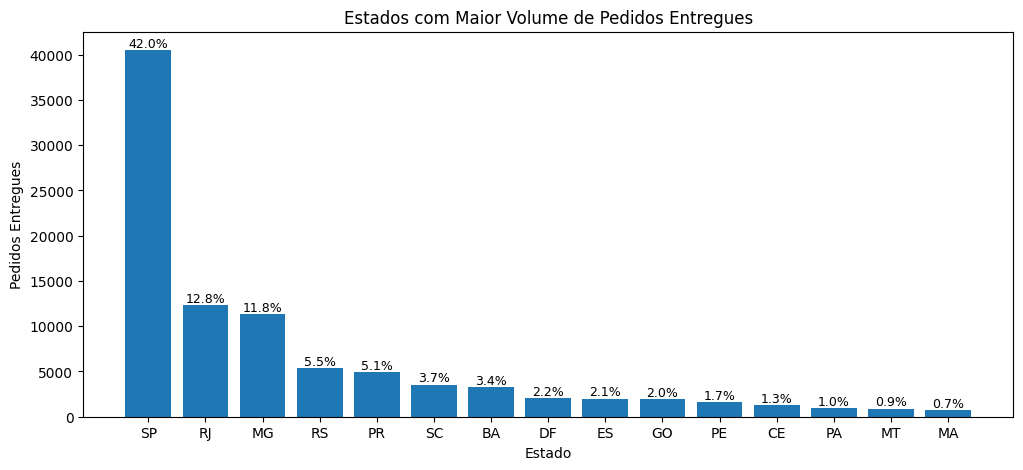

In [90]:
# Visualização da distribuição de pedidos entregues
plt.figure(figsize=(12,5))
bars = plt.bar(top15_states.index, top15_states.values)

plt.title('Estados com Maior Volume de Pedidos Entregues')
plt.xlabel('Estado')
plt.ylabel('Pedidos Entregues')

# Exibição do percentual de participação sobre cada barra
for bar, pct in zip(bars, top15_percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


#### **Observação - Gráfico de Barras Verticais**

Os estados do Sudeste concentram o maior volume de pedidos entregues, evidenciando a predominância dessa região no volume de vendas da plataforma. **São Paulo responde por aproximadamente 42% do total**, seguido por **Rio de Janeiro** e **Minas Gerais.**

Esse padrão sugere uma maior concentração de consumidores, aliada a uma infraestrutura logística mais desenvolvida, refletindo diretamente no volume de entregas realizadas.

### 2.1.2 Evolução do Volume dos Pedidos Entregues

In [91]:
# Criação da coluna ano-mes a partir da data de compra
df_delivered['ano_mes'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

In [92]:
# Agrupamento mensal do volume de pedidos entregues
vendas_mensais = (
    df_delivered
    .groupby('ano_mes')
    .size()
    .reset_index(name='quantidade_pedidos')
)

In [93]:
# Conversão do período para timestamp
vendas_mensais['ano_mes'] = vendas_mensais['ano_mes'].dt.to_timestamp()

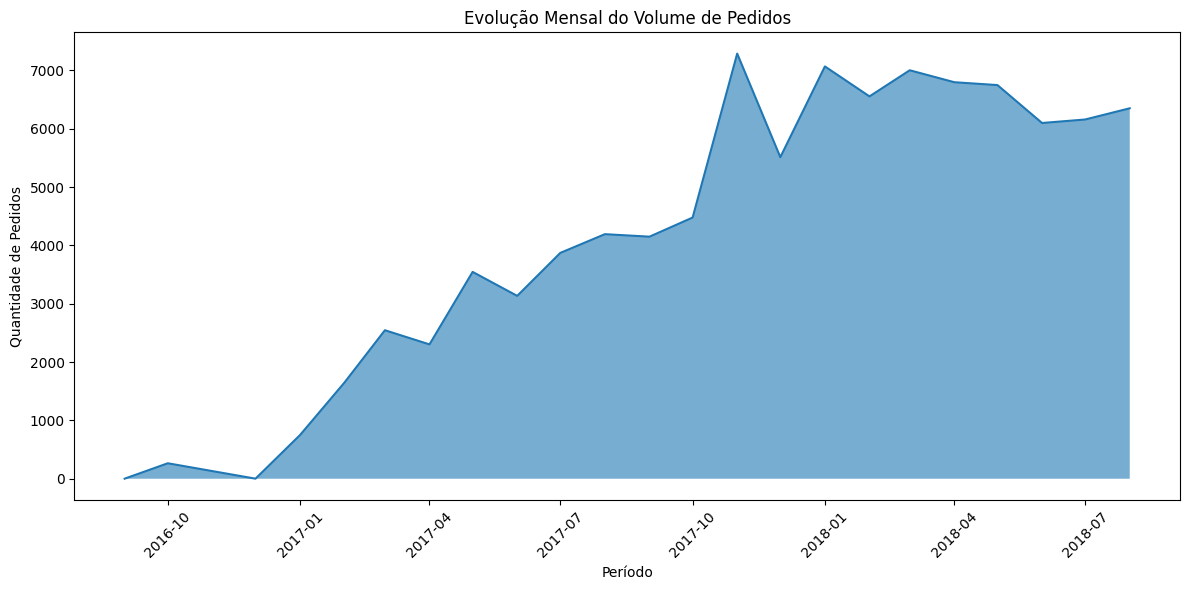

In [94]:
# Visualização do volume mensal de pedidos entregues
plt.figure(figsize=(12, 6))

plt.fill_between(
    vendas_mensais['ano_mes'],
    vendas_mensais['quantidade_pedidos'],
    alpha=0.6
)

plt.plot(
    vendas_mensais['ano_mes'],
    vendas_mensais['quantidade_pedidos']
)

plt.title('Evolução Mensal do Volume de Pedidos')
plt.xlabel('Período')
plt.ylabel('Quantidade de Pedidos')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Observação — Gráfico de Área**

Nota-se um **crescimento consistente** no volume de pedidos entregues ao longo de 2017, indicando uma fase de expansão da plataforma e aumento da adesão de consumidores.

O volume atinge seu pico no final de 2017 e, ao longo de 2018, mantém-se em um patamar elevado e relativamente **estável**, sugerindo a consolidação da operação e uma possível maturidade do mercado, com menor variação mensal na quantidade de pedidos entregues.


### 2.1.3 Proporção dos Métodos de Pagamento

In [95]:
# Preparação e cálculo da proporção dos métodos de pagamento
payment_labels = {
    'credit_card': 'Cartão de crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Cartão de débito'
}

payment_counts = (
    df_payments['payment_type']
    .value_counts()
    .drop('not_defined', errors='ignore')
    .rename(payment_labels)
)

percentuais = payment_counts / payment_counts.sum() * 100

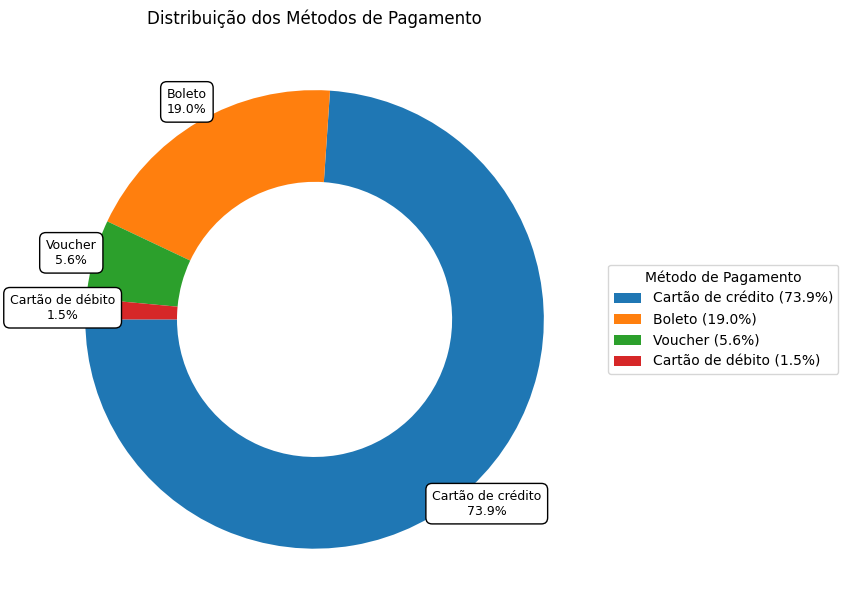

In [96]:
# Visualização da distribuição dos métodos de pagamento
fig, ax = plt.subplots(figsize=(8, 7))

labels = payment_counts.index.tolist()

# Função personalizada para exibir nome do método e percentual em cada fatia
def autopct_nome_percentual(pct):
    total = sum(payment_counts.values)
    valor = int(round(pct * total / 100))
    label = labels[autopct_nome_percentual.i]
    autopct_nome_percentual.i += 1
    return f'{label}\n{pct:.1f}%'

# Contador auxiliar para sincronizar rótulos com as fatias
autopct_nome_percentual.i = 0

wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    autopct=autopct_nome_percentual,
    startangle=180,
    pctdistance=1.10,
    wedgeprops=dict(width=0.4)
)

# Ajustes visuais dos rótulos
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)
    autotext.set_bbox(dict(boxstyle='round,pad=0.5', fc='white', ec='black'))

legend_labels = [
    f'{label} ({percentuais[label]:.1f}%)'
    for label in payment_counts.index
]

ax.legend(
    wedges,
    legend_labels,
    title='Método de Pagamento',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

ax.set_title('Distribuição dos Métodos de Pagamento')

plt.tight_layout()
plt.show()

#### **Observação – Métodos de Pagamento**

O pagamento via **cartão de crédito** representa a ampla maioria das transações, concentrando aproximadamente **74%** do total.
O **boleto bancário** aparece como o segundo método mais utilizado, com cerca de **19%**, enquanto **voucher** e **cartão de débito** possuem participação residual.

A visualização reforça a forte dependência do e-commerce em meios de pagamento eletrônicos, especialmente cartão de crédito.


### 2.1.4 Evolução dos Métodos de Pagamentos

In [97]:
# Criação da coluna ano-mês a partir da data de compra
df_orders['ano_mes'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

# Associação do período (ano-mês) aos registros de pagamento
df_payments = df_payments.merge(
    df_orders[['order_id', 'ano_mes']],
    on='order_id',
    how='left'
)

# Remoção de registros com método de pagamento indefinido
df_payments = df_payments[
    df_payments['payment_type'] != 'not_defined'
]

# Contagem mensal de pagamentos por método
pagamentos_mensais = (
    df_payments
    .groupby(['ano_mes', 'payment_type'])
    .size()
    .reset_index(name='qtd')
)

# Identificação de meses com todos os métodos de pagamento disponíveis
metodos_por_mes = (
    pagamentos_mensais
    .groupby('ano_mes')['payment_type']
    .nunique()
)

meses_validos = metodos_por_mes[
    metodos_por_mes == len(payment_labels)
].index

pagamentos_mensais = pagamentos_mensais[
    pagamentos_mensais['ano_mes'].isin(meses_validos)
]

# Cálculo da proporção de cada método dentro do mês
pagamentos_mensais['proporcao'] = (
    pagamentos_mensais
    .groupby('ano_mes')['qtd']
    .transform(lambda x: x / x.sum())
)

# Reestruturação dos dados para formato de séries temporais
pagamentos_pivot = pagamentos_mensais.pivot(
    index='ano_mes',
    columns='payment_type',
    values='proporcao'
)

# Conversão do índice de período para datetime
pagamentos_pivot.index = pagamentos_pivot.index.to_timestamp()

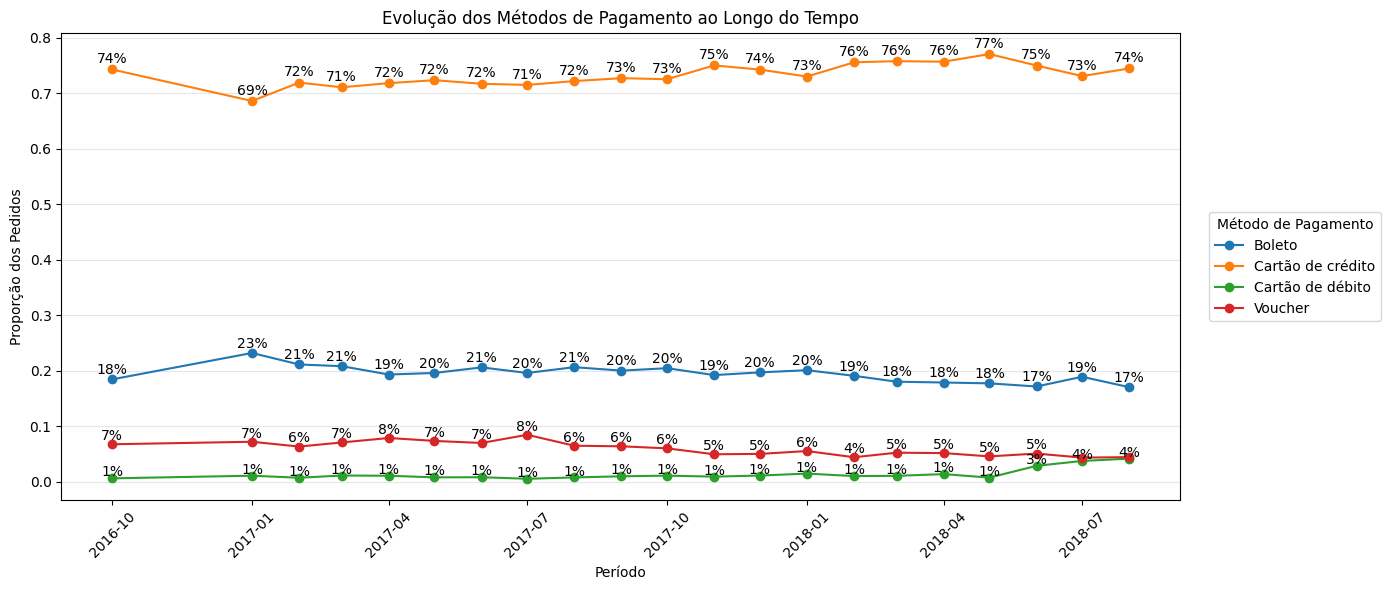

In [98]:
# Visualização da evolução da proporção dos métodos de pagamento ao longo do tempo
plt.figure(figsize=(14, 6))

# Ajustes verticais para evitar sobreposição de rótulos
offsets = {
    'credit_card': 0.006,
    'boleto': 0.004,
    'voucher': 0.002,
    'debit_card': -0.002
}

# Plot das séries temporais por método de pagamento
for metodo in pagamentos_pivot.columns:
    plt.plot(
        pagamentos_pivot.index,
        pagamentos_pivot[metodo],
        marker='o',
        label=payment_labels.get(metodo, metodo)
    )

# Anotação das proporções em cada período
for mes in pagamentos_pivot.index:

    valores_mes = pagamentos_pivot.loc[mes]
    mostrados = set()

    for metodo, valor in valores_mes.items():

        pct = f'{valor:.0%}'

        # Evita repetição de rótulos iguais no mesmo mês
        if pct in mostrados:
            continue

        plt.text(
            mes,
            valor + offsets.get(metodo, 0.003),
            pct,
            ha='center',
            va='bottom',
            fontsize=10
        )

        mostrados.add(pct)

# Ajustes finais de apresentação
plt.title('Evolução dos Métodos de Pagamento ao Longo do Tempo')
plt.xlabel('Período')
plt.ylabel('Proporção dos Pedidos')

plt.xticks(rotation=45)

plt.legend(
    title='Método de Pagamento',
    bbox_to_anchor=(1.02, 0.5),
    loc='center left'
)

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Observação - Gráfico de Linhas**

A partir do gráfico de linhas, observa-se que o **cartão de crédito apresentou crescimento em 2018** em relação aos anos anteriores, consolidando-se como o principal método de pagamento ao longo do período analisado.

Em contrapartida, métodos como **boleto bancário e voucher demonstraram uma trajetória de queda gradual e contínua**, indicando uma redução gradual de sua participação relativa nos pedidos.

O **cartão de débito manteve participação reduzida**, com variações pontuais ao longo do tempo, mas sem impacto significativo na composição geral dos métodos de pagamento.

### 2.1.5 Comparação entre Tempo Médio e Mediano das Etapas do Pedido

In [99]:
# Cálculo do tempo (em horas) entre as principais etapas do pedido
df_orders['purchase_to_approved_h'] = (
    df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

df_orders['approved_to_carrier_h'] = (
    df_orders['order_delivered_carrier_date'] - df_orders['order_approved_at']
).dt.total_seconds() / 3600

df_orders['carrier_to_customer_h'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_delivered_carrier_date']
).dt.total_seconds() / 3600

# Seleção das métricas de tempo para análise comparativa
time_cols = [
    'purchase_to_approved_h',
    'approved_to_carrier_h',
    'carrier_to_customer_h'
]

labels = [
    'Compra → Aprovação',
    'Aprovação → Envio',
    'Envio → Entrega'
]

# Cálculo da média e mediana para identificar assimetria nos tempos
mean_times = df_orders[time_cols].mean()
median_times = df_orders[time_cols].median()

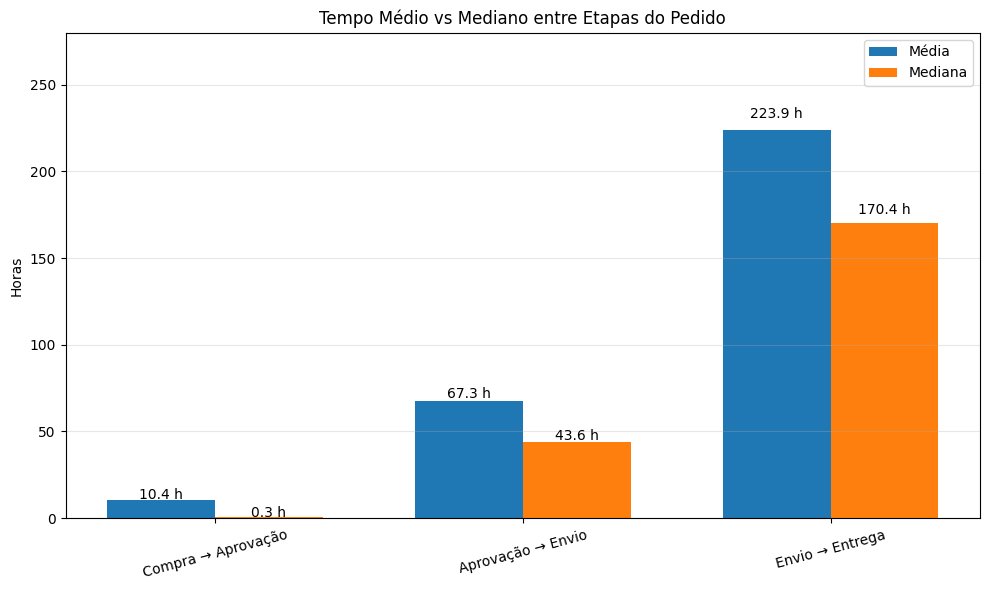

In [100]:
# Configuração do gráfico
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))

# Construção das barras comparativas (média vs mediana)
bars_mean = plt.bar(
    x - width/2,
    mean_times,
    width,
    label='Média'
)

bars_median = plt.bar(
    x + width/2,
    median_times,
    width,
    label='Mediana'
)

plt.xticks(x, labels, rotation=15)
plt.ylabel('Horas')
plt.title('Tempo Médio vs Mediano entre Etapas do Pedido')
plt.legend()

max_value = max(mean_times.max(), median_times.max())
plt.ylim(0, max_value * 1.25)

plt.grid(axis='y', alpha=0.3)

# Função auxiliar para exibição dos valores nas barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (height * 0.03),
            f'{height:.1f} h',
            ha='center',
            fontsize=10
        )

add_labels(bars_mean)
add_labels(bars_median)

plt.tight_layout()
plt.show()

#### **Observação - Comparação Gráfico de Barras**

A diferença observada entre média e mediana ao longo das etapas do processo indica a presença de **variações relevantes nos tempos de execução**. Embora esse comportamento possa ser esperado em operações de grande escala, especialmente na etapa logística, a magnitude dessas diferenças sugere que parte dos pedidos enfrenta **atrasos significativos** em relação ao fluxo típico.

Caso essas estimativas não estejam alinhadas às **expectativas operacionais** ou aos prazos definidos pela empresa, torna-se necessário investigar mais profundamente os possíveis gargalos, exceções ou falhas recorrentes em cada etapa, a fim de avaliar oportunidades de melhoria e otimização do processo como um todo.

### 2.1.6 Proporção de Pedidos Entregues no Prazo Estimado

In [101]:
# Seleção de pedidos efetivamente entregues com datas válidas para análise de prazo
df_delivered = df_delivered[
    df_delivered['order_delivered_customer_date'].notna() &
    df_delivered['order_estimated_delivery_date'].notna()
].copy()

# Classificação dos pedidos conforme cumprimento do prazo estimado
df_delivered['status_prazo'] = (
    df_delivered['order_delivered_customer_date']
    <=
    df_delivered['order_estimated_delivery_date']
)

# Padronização dos rótulos de prazo
df_delivered['status_prazo'] = df_delivered['status_prazo'].map({
    True: 'Dentro do prazo',
    False: 'Fora do prazo'
})

# Contagem absoluta e proporção percentual dos pedidos por status de prazo
prazo_counts = df_delivered['status_prazo'].value_counts()
prazo_percent = prazo_counts / prazo_counts.sum() * 100

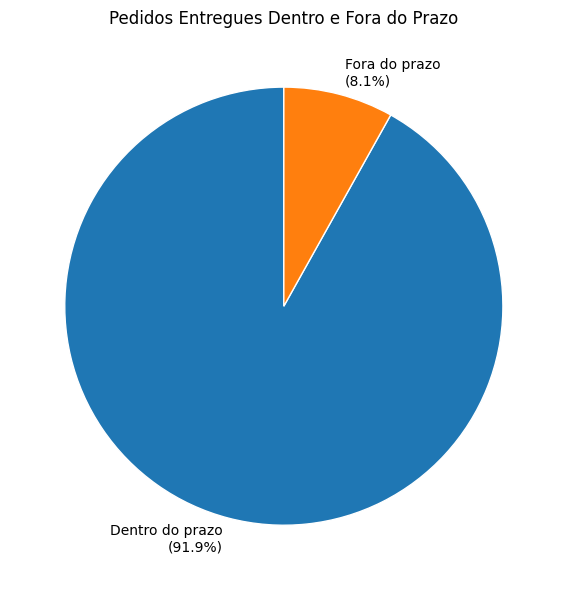

In [102]:
# Visualização da proporção de pedidos entregues dentro e fora do prazo
plt.figure(figsize=(6, 6))

plt.pie(
    prazo_counts,
    labels=[
        f'{label}\n({prazo_percent[label]:.1f}%)'
        for label in prazo_counts.index
    ],
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Pedidos Entregues Dentro e Fora do Prazo')
plt.tight_layout()
plt.show()


#### **Observação - Gráfico de Pizza**

A maior parte dos pedidos foi entregue dentro do prazo estimado, indicando boa conformidade com a logística de entregas. Ainda assim, uma parcela relevante desses pedidos **extrapolou a estimativa**, o que sugere oportunidades de melhoria nos processos logísticos, especialmente nas etapas de transporte e distribuição.

### 2.1.7 Relação entre Avaliação dos Clientes e Volume Médio de Pedidos Entregues




In [103]:
# Seleção de colunas necessárias dos pedidos entregues
df_reviews_delivered = df_delivered[
    ['order_id', 'order_purchase_timestamp']
].copy()

# Criação da coluna ano-mês
df_reviews_delivered['ano_mes'] = (
    df_reviews_delivered['order_purchase_timestamp']
    .dt.to_period('M')
)

# Integração com as avaliações dos clientes
df_reviews_delivered = df_reviews_delivered.merge(
    df_reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# Contagem mensal de pedidos entregues por score de avaliação
contagem_mensal = (
    df_reviews_delivered
    .groupby(['ano_mes', 'review_score'])
    .size()
    .reset_index(name='qtd_pedidos')
)

# Cálculo do volume médio mensal de pedidos por score
media_por_score = (
    contagem_mensal
    .groupby('review_score')['qtd_pedidos']
    .mean()
    .reset_index()
)

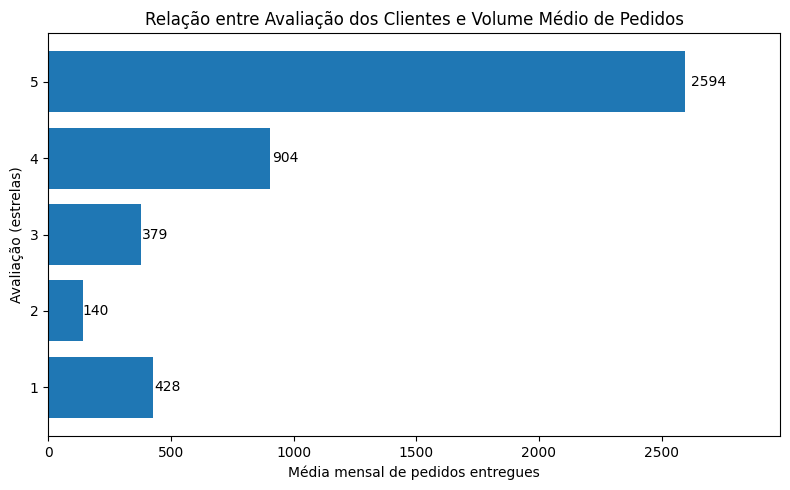

In [104]:
# Visualização do volume médio mensal de pedidos entregues por avaliação dos clientes
plt.figure(figsize=(8, 5))

plt.barh(
    media_por_score['review_score'].astype(str),
    media_por_score['qtd_pedidos']
)

plt.xlabel('Média mensal de pedidos entregues')
plt.ylabel('Avaliação (estrelas)')
plt.title('Relação entre Avaliação dos Clientes e Volume Médio de Pedidos')

# Exibição dos valores nas barras
for i, valor in enumerate(media_por_score['qtd_pedidos']):
    plt.text(
        valor + (valor * 0.01),
        i,
        f'{valor:.0f}',
        va='center'
    )

plt.xlim(0, media_por_score['qtd_pedidos'].max() * 1.15)
plt.tight_layout()
plt.show()

#### **Observação - Gráfico de Barras Horizontais**

Observa-se uma diferença expressiva no volume médio de pedidos entregues conforme a avaliação atribuída pelos clientes. Pedidos com **avaliações mais altas**, especialmente com **5 estrelas**, concentram a **maior parte do volume**, enquanto avaliações baixas apresentam participação significativamente menor.

Esse comportamento indica que a percepção do cliente, refletida no **review score**, exerce **forte influência sobre o desempenho de vendas** da empresa, reforçando a importância da qualidade do serviço, da experiência de entrega e do atendimento ao cliente como fatores estratégicos para a sustentabilidade e crescimento do negócio.

## 3.1 Conclusão Parte 1


A parte inicial do projeto foi desenvolvido com o objetivo de apresentar um **contexto geral de análise de dados**, partindo de um conjunto de datasets de e-commerce que exigiu etapas consistentes de **limpeza, validação, integração e exploração dos dados** antes da extração de insights.

Ao longo da análise, o foco não esteve em responder uma única pergunta de negócio específica, mas em **mapear comportamentos, padrões e relações relevantes** entre pedidos, clientes, pagamentos, avaliações e entregas. Essa abordagem permitiu observar tendências importantes, como a distribuição geográfica dos pedidos, a evolução temporal do volume de vendas, o comportamento dos métodos de pagamento, o cumprimento de prazos logísticos e a relação entre avaliações dos clientes e o volume médio de pedidos entregues.

Alguns resultados levantam **possibilidades claras de aprofundamento analítico**, como:

* a diferença entre médias e medianas nos tempos entre etapas do pedido, que sugere assimetrias e possíveis gargalos operacionais;

* o impacto das avaliações dos clientes sobre o volume médio de pedidos, que pode ser investigado sob a ótica de causalidade, recorrência ou sazonalidade;

* o comportamento dos métodos de pagamento ao longo do tempo, que pode indicar mudanças no perfil do consumidor ou efeitos de campanhas e condições comerciais.

Essas análises adicionais não foram exploradas em profundidade neste projeto por dependerem de **objetivos específicos de negócio**, como foco em logística, experiência do cliente, marketing ou performance operacional. Em um contexto corporativo, tais objetivos direcionariam métricas, recortes temporais e metodologias mais detalhadas.

Dessa forma, este trabalho se propõe a demonstrar a **capacidade de estruturar dados, conduzir uma análise exploratória consistente e comunicar insights de forma clara**, estabelecendo uma base sólida para análises direcionadas, construção de dashboards em ferramentas de BI ou aplicações futuras de modelos analíticos mais avançados.

## 4.1 Análise Aprofundada: Fatores que Influenciam a Satisfação do Cliente

### Contexto e Objetivo

Na análise exploratória, observamos que o review score
apresenta forte concentração em avaliações positivas (4-5
estrelas), enquanto avaliações negativas representam menor
volume de pedidos.

Esta análise investiga **quais fatores operacionais e
comerciais estão associados à satisfação do cliente**,
buscando identificar padrões que possam orientar melhorias
no processo de venda e entrega.

O objetivo é responder: **é possível prever ou explicar o
nível de satisfação com base em características do pedido?**

### Questões de Investigação

1. **Tempo de entrega impacta o review score?** Pedidos
   entregues mais rapidamente recebem avaliações melhores?

2. **Valor do pedido influencia a satisfação?** Clientes que
   gastam mais avaliam melhor?

3. **Método de pagamento tem relação com reviews?** Há
   diferença entre cartão de crédito, boleto, etc?

4. **Existem outliers críticos?** Pedidos extremos (muito
   caros, muito demorados) apresentam padrões distintos?

### Metodologia

**Técnicas utilizadas:**
- **Análise de outliers** (IQR e boxplots) para identificar
  casos extremos
- **Correlação de Pearson** para medir relação linear entre
  variáveis numéricas
- **Regressão Linear Simples** para modelar relação entre
  tempo de entrega e review score
- **Análise de grupos** (segmentação por quartis) para
  comparar comportamentos

In [105]:
# Importando bibliotecas adicionais para análise estatística
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [106]:
# Configurações de visualização
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 4.2 Preparação dos Dados e Análise Exploratória

### Tempo de entrega impacta o review score?

In [107]:
# Calculo do tempo TOTAL de entrega
df_orders['tempo_entrega_total_h'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Conversão para dias
df_orders['tempo_entrega_dias'] = df_orders['tempo_entrega_total_h'] / 24

In [108]:
# Mescla das tabelas para construção do dataset de análise
df_analise = df_orders[['order_id', 'order_status', 'tempo_entrega_dias']].copy()

# Adição das avaliações dos clientes
df_analise = df_analise.merge(
    df_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# Agregação do valor total dos pagamentos por pedido
df_payments_total = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
df_analise = df_analise.merge(
    df_payments_total,
    on='order_id',
    how='left'
)

In [109]:
# Aplicação de filtros para seleção de pedidos válidos
df_analise = df_analise[
    (df_analise['order_status'] == 'delivered') &
    (df_analise['review_score'].notna()) &
    (df_analise['tempo_entrega_dias'].notna()) &
    (df_analise['payment_value'].notna()) &
    (df_analise['tempo_entrega_dias'] > 0)  # Remover tempos inválidos/negativos
].copy()

# Visão geral do dataset resultante
print(f"Total de pedidos para análise: {len(df_analise):,}")
print(f"\nDataset original (df_orders): {len(df_orders):,} pedidos")
print(f"Após filtros: {len(df_analise):,} pedidos ({len(df_analise)/len(df_orders)*100:.1f}%)")

Total de pedidos para análise: 96,352

Dataset original (df_orders): 99,441 pedidos
Após filtros: 96,352 pedidos (96.9%)


In [110]:
df_analise.head()

,order_id,order_status,tempo_entrega_dias,review_score,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,8.436574,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,13.782037,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,9.394213,5.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,13.208750,5.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2.873877,5.0,28.62


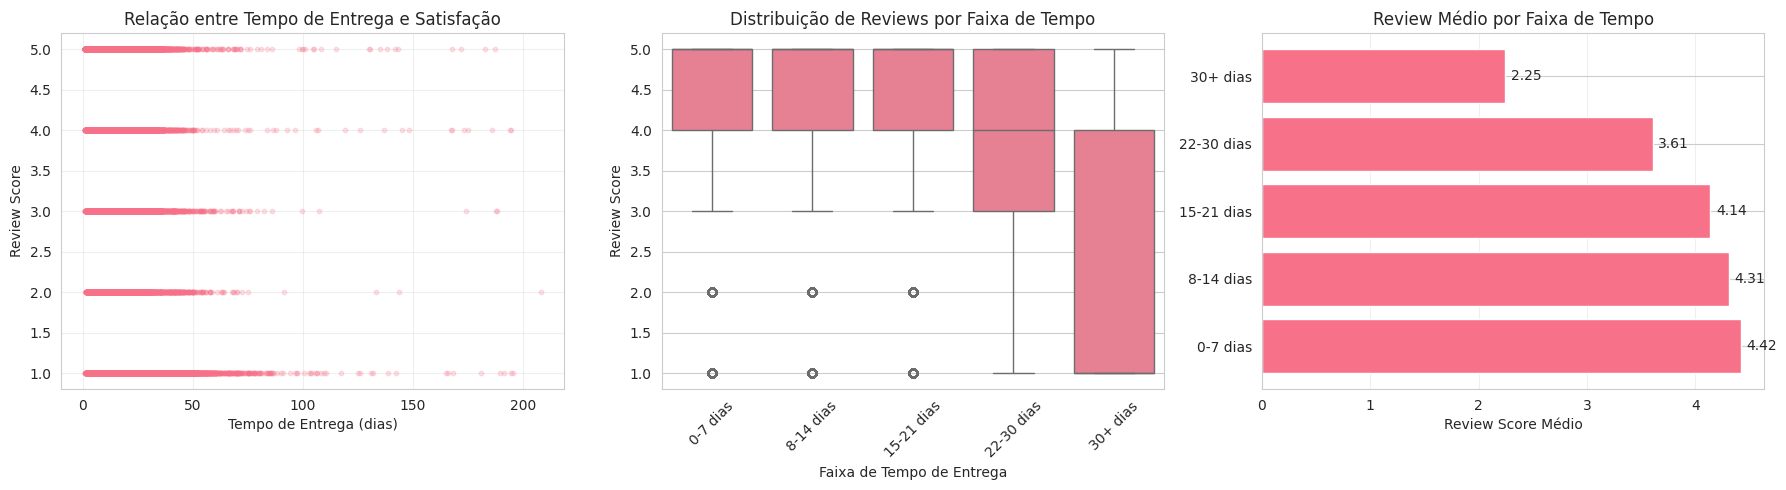

In [111]:
# Criação de faixas de tempo para análise comparativa
df_analise['faixa_tempo'] = pd.cut(df_analise['tempo_entrega_dias'],
                                     bins=[0, 7, 14, 21, 30, 100],
                                     labels=['0-7 dias', '8-14 dias', '15-21 dias',
                                             '22-30 dias', '30+ dias'])

# Visualização da relação entre tempo de entrega e satisfação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(df_analise['tempo_entrega_dias'],
                df_analise['review_score'],
                alpha=0.2, s=10)
axes[0].set_xlabel('Tempo de Entrega (dias)')
axes[0].set_ylabel('Review Score')
axes[0].set_title('Relação entre Tempo de Entrega e Satisfação')
axes[0].grid(True, alpha=0.3)

# Boxplot por faixa de tempo
sns.boxplot(data=df_analise, x='faixa_tempo', y='review_score', ax=axes[1])
axes[1].set_xlabel('Faixa de Tempo de Entrega')
axes[1].set_ylabel('Review Score')
axes[1].set_title('Distribuição de Reviews por Faixa de Tempo')
axes[1].tick_params(axis='x', rotation=45)

# Review médio por faixa
media_review = df_analise.groupby('faixa_tempo')['review_score'].mean().sort_values(ascending=False)
axes[2].barh(range(len(media_review)), media_review.values)
axes[2].set_yticks(range(len(media_review)))
axes[2].set_yticklabels(media_review.index)
axes[2].set_xlabel('Review Score Médio')
axes[2].set_title('Review Médio por Faixa de Tempo')
axes[2].grid(True, alpha=0.3, axis='x')

for i, v in enumerate(media_review.values):
    axes[2].text(v + 0.05, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

In [112]:
# Cálculo da correlação de Pearson
correlacao, p_value = stats.pearsonr(df_analise['tempo_entrega_dias'],
                                      df_analise['review_score'])

# Resultados em DataFrame
pd.DataFrame({
    'Métrica': ['Correlação de Pearson', 'P-value', 'Significância Estatística'],
    'Valor': [
        f'{correlacao:.4f}',
        f'{p_value:.4e}',
        'Sim (p < 0.05)' if p_value < 0.05 else 'Não (p >= 0.05)'
    ]
})


,Métrica,Valor
0,Correlação de Pearson,-0.3337
1,P-value,0.0000e+00
2,Significância Estatística,Sim (p < 0.05)


In [113]:
# Agregação de métricas por faixa de tempo
df_analise.groupby('faixa_tempo').agg({
    'review_score': ['mean', 'median', 'count'],
    'tempo_entrega_dias': ['mean', 'median']
}).round(2)

review_score               tempo_entrega_dias       
                    mean median  count               mean median
faixa_tempo                                                     
0-7 dias            4.42    5.0  26040               4.66   4.94
8-14 dias           4.31    5.0  40214              10.09   9.96
15-21 dias          4.14    5.0  17710              16.92  16.70
22-30 dias          3.61    4.0   7934              24.56  24.14
30+ dias            2.25    1.0   4393              40.11  36.86

#### **Observação - Tempo de Entrega vs Satisfação**

A análise demonstra **correlação negativa moderada** (r = -0.334, p < 0.05) entre tempo de entrega e satisfação do cliente.

Entregas em **até 7 dias** registram review médio de **4.42**, enquanto entregas **acima de 30 dias** apresentam média de **2.25** — uma redução próxima a 50% na satisfação.

A relação é estatisticamente significativa e reforça que o **tempo de entrega é fator crítico** na experiência do cliente. Atrasos superiores a 30 dias (média de 40 dias, mediana de 37 dias) comprometem severamente a satisfação, com review mediano de apenas **1.0** (avaliação mínima). Este grupo representa
4.393 pedidos do conjunto analisado, evidenciando um problema logístico que impacta diretamente a percepção de qualidade do serviço.

### Valor do pedido influencia na avaliação?

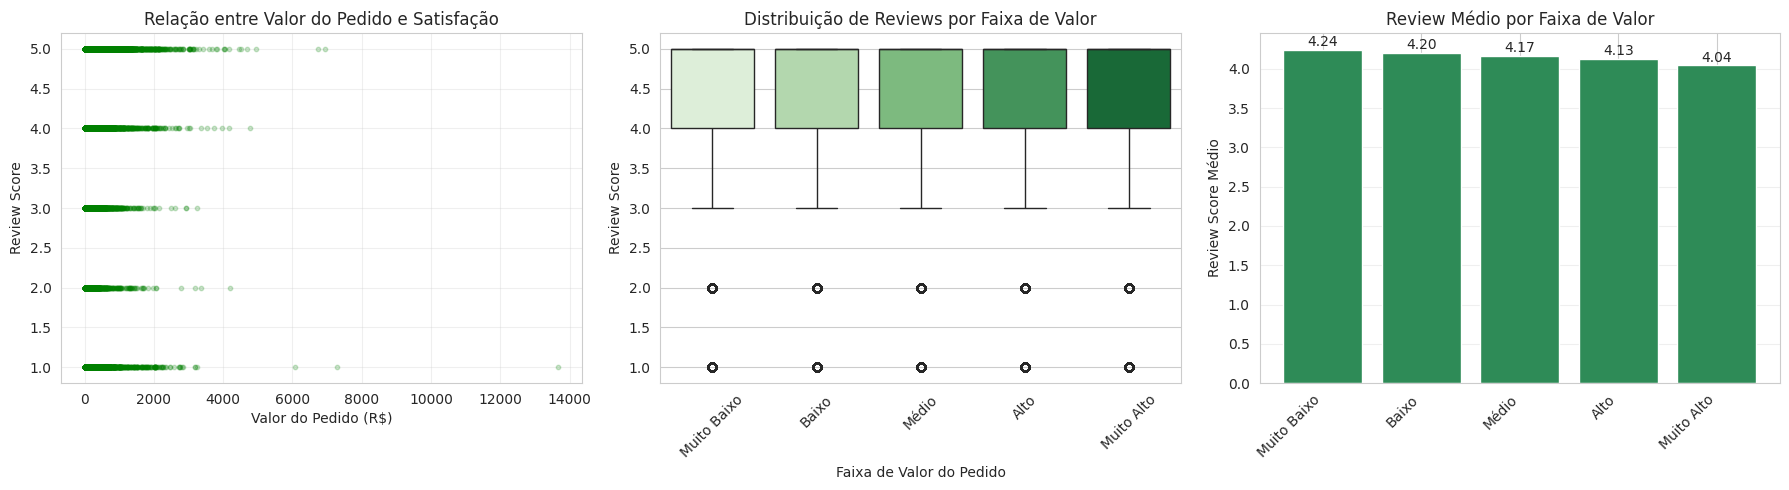

In [114]:
# Criação de faixas de valor para análise comparativa (quintis)
df_analise['faixa_valor'] = pd.qcut(df_analise['payment_value'],
                                     q=5,
                                     labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto'],
                                     duplicates='drop')

# Visualização da relação entre valor do pedido e satisfação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(df_analise['payment_value'],
                df_analise['review_score'],
                alpha=0.2, s=10, color='green')
axes[0].set_xlabel('Valor do Pedido (R$)')
axes[0].set_ylabel('Review Score')
axes[0].set_title('Relação entre Valor do Pedido e Satisfação')
axes[0].grid(True, alpha=0.3)

# Boxplot por faixa de valor
sns.boxplot(data=df_analise, x='faixa_valor', y='review_score', ax=axes[1], palette='Greens')
axes[1].set_xlabel('Faixa de Valor do Pedido')
axes[1].set_ylabel('Review Score')
axes[1].set_title('Distribuição de Reviews por Faixa de Valor')
axes[1].tick_params(axis='x', rotation=45)

# Review médio por faixa de valor
media_review_valor = df_analise.groupby('faixa_valor')['review_score'].mean()
axes[2].bar(range(len(media_review_valor)), media_review_valor.values, color='seagreen')
axes[2].set_xticks(range(len(media_review_valor)))
axes[2].set_xticklabels(media_review_valor.index, rotation=45, ha='right')
axes[2].set_ylabel('Review Score Médio')
axes[2].set_title('Review Médio por Faixa de Valor')
axes[2].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(media_review_valor.values):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

In [115]:
# Cálculo da correlação de Pearson
correlacao_valor, p_value_valor = stats.pearsonr(df_analise['payment_value'],
                                                   df_analise['review_score'])

# Resultados
pd.DataFrame({
    'Métrica': ['Correlação de Pearson', 'P-value', 'Significância Estatística'],
    'Valor': [
        f'{correlacao_valor:.4f}',
        f'{p_value_valor:.4e}',
        'Sim (p < 0.05)' if p_value_valor < 0.05 else 'Não (p >= 0.05)'
    ]
})


,Métrica,Valor
0,Correlação de Pearson,-0.0421
1,P-value,4.1250e-39
2,Significância Estatística,Sim (p < 0.05)


In [116]:
# Agregação de métricas por faixa de valor
df_analise.groupby('faixa_valor').agg({
    'review_score': ['mean', 'median', 'count'],
    'payment_value': ['mean', 'median', 'min', 'max']
}).round(2)

review_score               payment_value                          
                    mean median  count          mean  median     min       max
faixa_valor                                                                   
Muito Baixo         4.24    5.0  19274         39.11   39.52    9.59     54.32
Baixo               4.20    5.0  19268         68.96   68.38   54.33     85.16
Médio               4.17    5.0  19271        105.40  105.13   85.17    128.20
Alto                4.13    5.0  19268        160.04  158.21  128.21    201.47
Muito Alto          4.04    5.0  19271        423.70  305.55  201.49  13664.08

#### **Observação - Valor do Pedido vs Satisfação**

A análise identifica **correlação negativa fraca** (r = -0.042, p < 0.05) entre valor do pedido e satisfação do cliente. Embora estatisticamente significativa, a magnitude da correlação é baixa quando comparada a outros fatores analisados.

A visualização por faixas de valor demonstra variação de **4.24 a 4.04** no review médio entre pedidos de valor muito baixo e muito alto, uma diferença de 0.20 pontos. Essa amplitude reduzida sugere que o valor do pedido apresenta **influência limitada** na avaliação final.

Em comparação com o tempo de entrega (r = -0.334), o valor pago demonstra menor poder explicativo sobre a satisfação. Esse padrão indica que aspectos **operacionais e de experiência** podem ter maior peso na percepção do cliente do que o investimento realizado na compra.

### Método de pagamento tem relação com reviews?

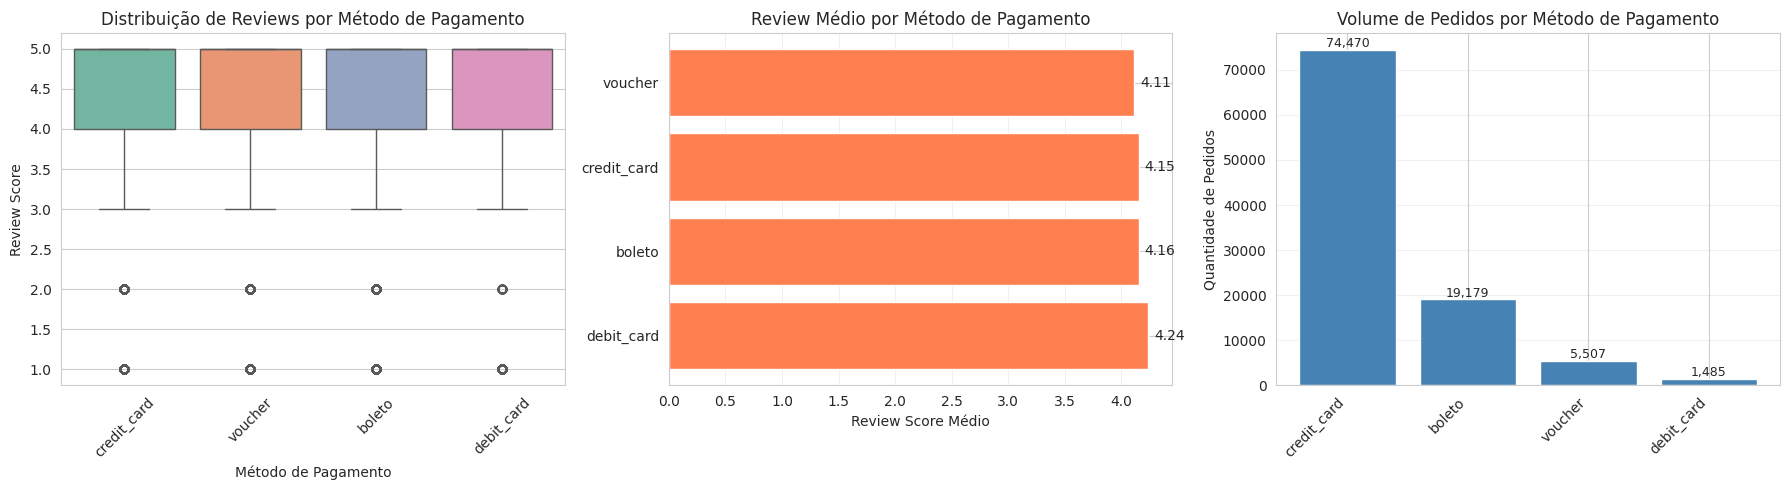

In [117]:
# Merge com dados de método de pagamento
df_analise_payment = df_analise.merge(
    df_payments[['order_id', 'payment_type']],
    on='order_id',
    how='left'
)

# Visualização da relação entre método de pagamento e satisfação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot por tipo de pagamento
sns.boxplot(data=df_analise_payment, x='payment_type', y='review_score', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Método de Pagamento')
axes[0].set_ylabel('Review Score')
axes[0].set_title('Distribuição de Reviews por Método de Pagamento')
axes[0].tick_params(axis='x', rotation=45)

# Review médio por método
media_review_payment = df_analise_payment.groupby('payment_type')['review_score'].mean().sort_values(ascending=False)
axes[1].barh(range(len(media_review_payment)), media_review_payment.values, color='coral')
axes[1].set_yticks(range(len(media_review_payment)))
axes[1].set_yticklabels(media_review_payment.index)
axes[1].set_xlabel('Review Score Médio')
axes[1].set_title('Review Médio por Método de Pagamento')
axes[1].grid(True, alpha=0.3, axis='x')

for i, v in enumerate(media_review_payment.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center')

# Contagem de pedidos por método
contagem_payment = df_analise_payment['payment_type'].value_counts()
axes[2].bar(range(len(contagem_payment)), contagem_payment.values, color='steelblue')
axes[2].set_xticks(range(len(contagem_payment)))
axes[2].set_xticklabels(contagem_payment.index, rotation=45, ha='right')
axes[2].set_ylabel('Quantidade de Pedidos')
axes[2].set_title('Volume de Pedidos por Método de Pagamento')
axes[2].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(contagem_payment.values):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [118]:
# Agregação de métricas por método de pagamento
df_analise_payment.groupby('payment_type').agg({
    'review_score': ['mean', 'median', 'count'],
    'payment_value': ['mean', 'median']
}).round(2)

review_score               payment_value        
                     mean median  count          mean  median
payment_type                                                 
boleto               4.16    5.0  19179        143.82   93.66
credit_card          4.15    5.0  74470        165.66  108.72
debit_card           4.24    5.0   1485        140.26   89.63
voucher              4.11    5.0   5507        136.11   89.36

In [119]:
# Teste ANOVA para verificar se há diferença significativa entre grupos
grupos = [group['review_score'].values for name, group in df_analise_payment.groupby('payment_type')]
f_statistic, p_value_anova = stats.f_oneway(*grupos)

# Resultados
pd.DataFrame({
    'Métrica': ['F-statistic', 'P-value', 'Diferença Significativa'],
    'Valor': [
        f'{f_statistic:.4f}',
        f'{p_value_anova:.4e}',
        'Sim (p < 0.05)' if p_value_anova < 0.05 else 'Não (p >= 0.05)'
    ]
})

,Métrica,Valor
0,F-statistic,4.0435
1,P-value,6.9515e-03
2,Diferença Significativa,Sim (p < 0.05)


#### **Observação - Método de Pagamento vs Satisfação**

O teste ANOVA identifica **diferença estatisticamente significativa** entre os métodos de pagamento (F = 4.044, p < 0.01), embora a magnitude dessa diferença seja limitada na prática.

A análise dos reviews médios por método apresenta variação de **4.11 a 4.24** entre os grupos, com cartão de débito registrando a maior média (4.24) e voucher a menor (4.11). Todos os métodos mantêm mediana de **5.0**, indicando
predominância de avaliações positivas independentemente da forma de pagamento.

É importante considerar a **distribuição amostral**: cartão de crédito representa **74.470 pedidos** (73% do total), enquanto cartão de débito possui apenas **1.485 pedidos** (1,5%). Os métodos com maior volume amostral — cartão de
crédito (4.15) e boleto (4.16) — apresentam médias praticamente idênticas, sugerindo que, para a maioria dos clientes, o método de pagamento exerce influência limitada sobre a satisfação final.

### Existem outliers críticos?

In [120]:
# Cálculo do IQR (Interquartile Range) para tempo de entrega
Q1 = df_analise['tempo_entrega_dias'].quantile(0.25)
Q3 = df_analise['tempo_entrega_dias'].quantile(0.75)
IQR = Q3 - Q1

# Limites para identificação de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificação de outliers
df_analise['outlier_tempo'] = (
    (df_analise['tempo_entrega_dias'] < limite_inferior) |
    (df_analise['tempo_entrega_dias'] > limite_superior)
)

# Separação dos grupos
df_outliers = df_analise[df_analise['outlier_tempo'] == True]
df_normais = df_analise[df_analise['outlier_tempo'] == False]

# Resumo estatístico
pd.DataFrame({
    'Métrica': ['Q1 (25%)', 'Q3 (75%)', 'IQR', 'Limite Inferior', 'Limite Superior',
                'Total Outliers', '% Outliers'],
    'Valor': [
        f'{Q1:.2f} dias',
        f'{Q3:.2f} dias',
        f'{IQR:.2f} dias',
        f'{limite_inferior:.2f} dias',
        f'{limite_superior:.2f} dias',
        f'{len(df_outliers):,} pedidos',
        f'{len(df_outliers)/len(df_analise)*100:.2f}%'
    ]
})

,Métrica,Valor
0,Q1 (25%),6.76 dias
1,Q3 (75%),15.68 dias
2,IQR,8.92 dias
3,Limite Inferior,-6.62 dias
4,Limite Superior,29.07 dias
5,Total Outliers,"4,868 pedidos"
6,% Outliers,5.05%


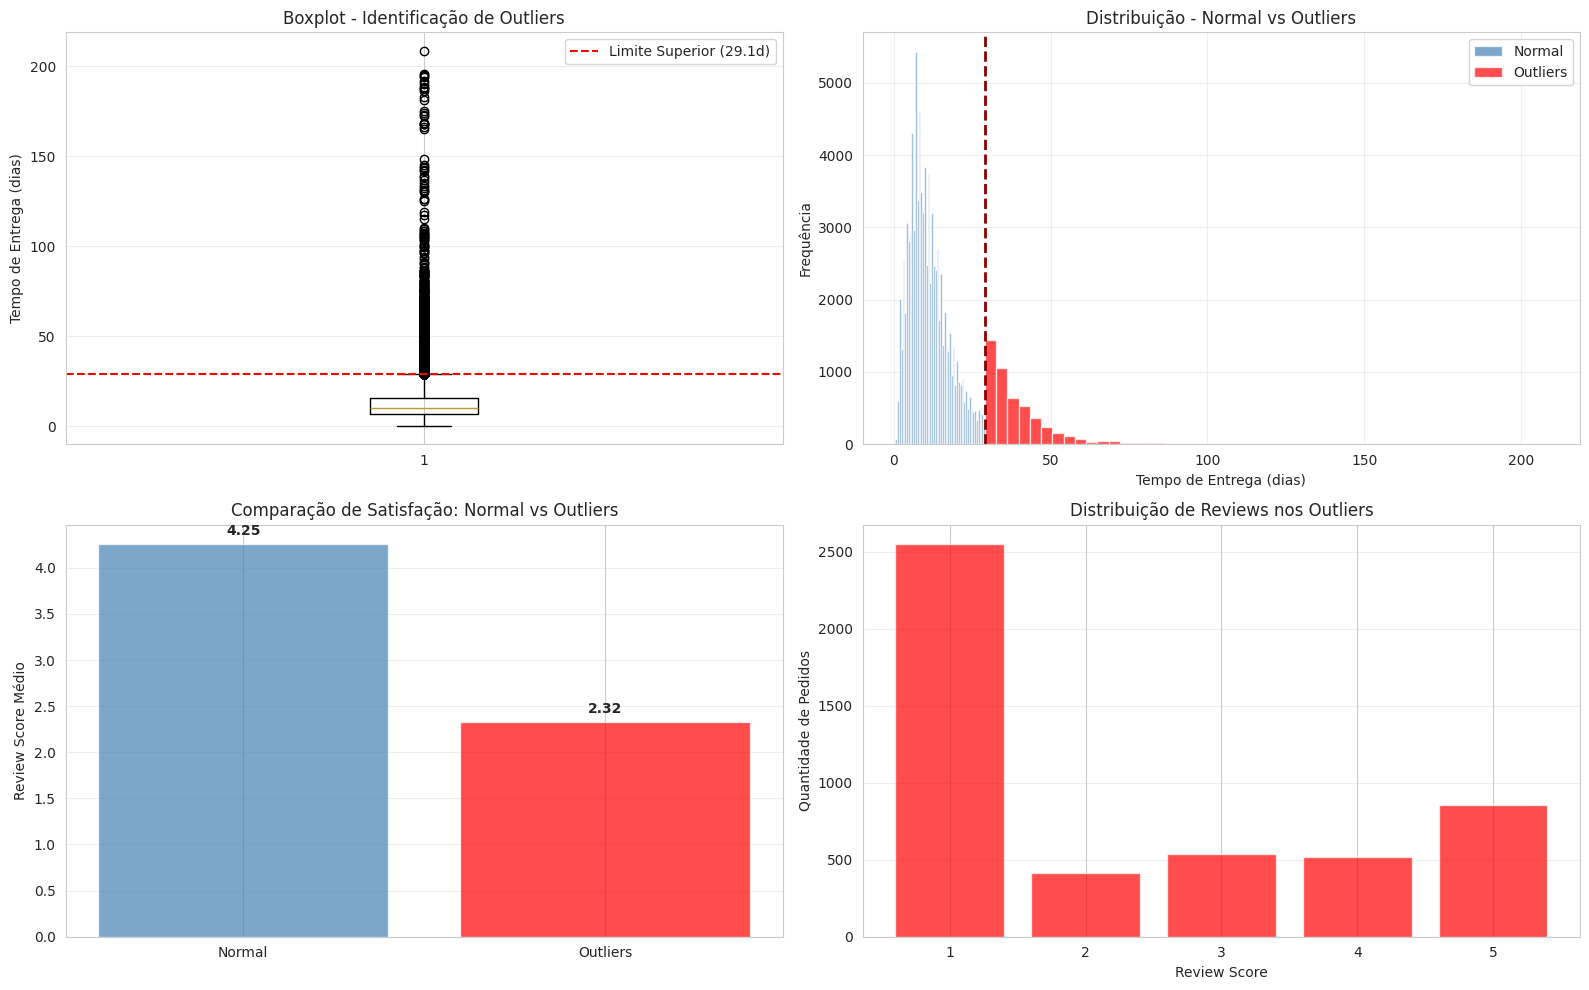

In [121]:
# Visualização comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Boxplot geral
axes[0, 0].boxplot(df_analise['tempo_entrega_dias'], vert=True)
axes[0, 0].axhline(y=limite_superior, color='r', linestyle='--', label=f'Limite Superior ({limite_superior:.1f}d)')
axes[0, 0].set_ylabel('Tempo de Entrega (dias)')
axes[0, 0].set_title('Boxplot - Identificação de Outliers')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Histograma com outliers destacados
axes[0, 1].hist(df_normais['tempo_entrega_dias'], bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[0, 1].hist(df_outliers['tempo_entrega_dias'], bins=50, alpha=0.7, label='Outliers', color='red')
axes[0, 1].axvline(limite_superior, color='darkred', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Tempo de Entrega (dias)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição - Normal vs Outliers')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Comparação de reviews: Normal vs Outliers
comparacao_reviews = pd.DataFrame({
    'Grupo': ['Normal', 'Outliers'],
    'Review Médio': [df_normais['review_score'].mean(), df_outliers['review_score'].mean()]
})
axes[1, 0].bar(comparacao_reviews['Grupo'], comparacao_reviews['Review Médio'],
               color=['steelblue', 'red'], alpha=0.7)
axes[1, 0].set_ylabel('Review Score Médio')
axes[1, 0].set_title('Comparação de Satisfação: Normal vs Outliers')
axes[1, 0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(comparacao_reviews['Review Médio']):
    axes[1, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Distribuição de reviews em outliers
review_outliers = df_outliers['review_score'].value_counts().sort_index()
axes[1, 1].bar(review_outliers.index, review_outliers.values, color='red', alpha=0.7)
axes[1, 1].set_xlabel('Review Score')
axes[1, 1].set_ylabel('Quantidade de Pedidos')
axes[1, 1].set_title('Distribuição de Reviews nos Outliers')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [122]:
# Comparação detalhada entre grupos
comparacao = pd.DataFrame({
    'Métrica': ['Quantidade', 'Tempo Médio (dias)', 'Tempo Mediano (dias)',
                'Review Médio', 'Review Mediano', 'Valor Médio (R$)'],
    'Normal': [
        f'{len(df_normais):,}',
        f'{df_normais["tempo_entrega_dias"].mean():.2f}',
        f'{df_normais["tempo_entrega_dias"].median():.2f}',
        f'{df_normais["review_score"].mean():.2f}',
        f'{df_normais["review_score"].median():.2f}',
        f'{df_normais["payment_value"].mean():.2f}'
    ],
    'Outliers': [
        f'{len(df_outliers):,}',
        f'{df_outliers["tempo_entrega_dias"].mean():.2f}',
        f'{df_outliers["tempo_entrega_dias"].median():.2f}',
        f'{df_outliers["review_score"].mean():.2f}',
        f'{df_outliers["review_score"].median():.2f}',
        f'{df_outliers["payment_value"].mean():.2f}'
    ]
})

comparacao

,Métrica,Normal,Outliers
0,Quantidade,"91,484","4,868"
1,Tempo Médio (dias),11.03,40.51
2,Tempo Mediano (dias),9.91,36.07
3,Review Médio,4.25,2.32
4,Review Mediano,5.00,1.00
5,Valor Médio (R$),157.45,196.90


In [123]:
# Teste t para comparar reviews entre grupos
t_statistic, p_value_ttest = stats.ttest_ind(df_normais['review_score'],
                                               df_outliers['review_score'])

pd.DataFrame({
    'Métrica': ['T-statistic', 'P-value', 'Diferença Significativa'],
    'Valor': [
        f'{t_statistic:.4f}',
        f'{p_value_ttest:.4e}',
        'Sim (p < 0.05)' if p_value_ttest < 0.05 else 'Não (p >= 0.05)'
    ]
})

,Métrica,Valor
0,T-statistic,108.0177
1,P-value,0.0000e+00
2,Diferença Significativa,Sim (p < 0.05)


#### **Observação - Outliers e Impacto na Satisfação**

A análise pelo método IQR identifica **4.868 pedidos outliers** (5,0% do total), caracterizados por tempos de entrega superiores ao limite estatístico. Esses casos apresentam tempo médio de **40,5 dias** (mediana de 36 dias), contrastando com **11 dias** (mediana de 10 dias) nos pedidos normais.

O impacto na satisfação é **substancial e estatisticamente significativo** (t = 108.02, p < 0.001). Pedidos outliers registram review médio de **2.32** e mediano de **1.0** (avaliação mínima), enquanto pedidos normais mantêm média de **4.25** e mediana de **5.0** (avaliação máxima), representando uma queda superior a 45% na satisfação.

Adicionalmente, outliers apresentam valor médio de pedido 25% superior (R\$ 196,90 vs R$ 157,45), sugerindo que **atrasos em pedidos de maior valor** podem gerar frustração amplificada, dado que expectativas tendem a ser proporcionais ao investimento realizado.

Esses casos críticos, embora representem parcela minoritária do volume total, exercem **impacto desproporcional** na experiência do cliente e podem comprometer a reputação e recorrência, demandando investigação de causas raiz e ações corretivas prioritárias.

## 4.3 Conclusão Parte 2

Esta análise aprofundada investigou os principais fatores associados à satisfação do cliente no contexto de e-commerce, revelando padrões estatisticamente significativos e de relevância prática para a gestão operacional.

**Principais achados:**

O **tempo de entrega** demonstrou ser o fator de maior impacto na satisfação (r = -0.334, p < 0.05), com entregas rápidas (até 7 dias) registrando review médio de 4.42, enquanto atrasos superiores a 30 dias resultam em média de 2.25 uma redução próxima a 50%. A identificação de outliers revelou que 5% dos pedidos apresentam atrasos críticos (média de 40 dias), comprometendo severamente a experiência do cliente com reviews medianos de 1.0.

O **valor do pedido** apresentou correlação fraca (r = -0.042), com variação limitada entre faixas (4.24 a 4.04), sugerindo que aspectos operacionais superam o investimento financeiro na determinação da satisfação. O **método de pagamento** também demonstrou influência limitada, com os métodos principais (cartão de crédito e boleto) apresentando médias praticamente idênticas (4.15 e 4.16).

**Escopo e recorte analítico:**

Esta investigação focou especificamente nas variáveis de **tempo de entrega, valor transacionado e método de pagamento**. O dataset contém informações adicionais relevantes, como localização geográfica de vendedores e compradores, categorias de produtos, e comentários textuais dos clientes que não foram exploradas nesta etapa.

**Limitações metodológicas:**

As correlações identificadas não estabelecem causalidade definitiva. Variáveis não incorporadas como categoria de produto, sazonalidade, perfil demográfico do cliente, e distância entre vendedor e comprador podem influenciar os resultados observados. Os modelos estatísticos empregados (correlação de Pearson, regressão linear simples) assumem relações lineares, enquanto a satisfação do cliente pode apresentar comportamentos não-lineares ou limiares críticos não capturados por essas técnicas.

**Direcionamento para investigações futuras:**

Os resultados estabelecem uma base sólida para análises direcionadas a objetivos específicos de negócio. Investigações futuras poderiam incorporar análise textual dos comentários para identificar causas de insatisfação, segmentação por categoria de produto para entender variações setoriais, análise geoespacial para otimização logística regional, ou desenvolvimento de modelos preditivos de satisfação incorporando múltiplas dimensões simultaneamente.